# Notebook 1 (v2): Preprocessing — MSD Liver → .npy Cache

### Changes vs baseline
- ✅ **Patient-level train/val split** saved to disk — no data leakage
- ✅ **2.5D slices** — each sample stores (z-1, z, z+1) as 3 channels
- ✅ **Negative slice sampling** — 10% of empty slices kept to reduce false positives
- ✅ **Per-dataset intensity statistics** computed and saved for normalisation reuse
- ✅ Cleaned-up, reproducible preprocessing pipeline


## 1. Install dependencies

In [1]:
!pip install nibabel simpleitk opencv-python tqdm scikit-learn

## 2. Imports

In [2]:
import os
import json
import random
import numpy as np
import nibabel as nib
import cv2
from tqdm import tqdm
import torch
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 3. Paths & Config

In [3]:
IMAGES_DIR   = "Task03_Liver/imagesTr"
LABELS_DIR   = "Task03_Liver/labelsTr"
IMAGES_TS_DIR = "Task03_Liver/imagesTs"

# ---- Cache root ----
CACHE_ROOT  = "msd_liver_cache_v2"
IMG_CACHE   = os.path.join(CACHE_ROOT, "images")
MSK_CACHE   = os.path.join(CACHE_ROOT, "masks")
SPLIT_FILE  = os.path.join(CACHE_ROOT, "patient_split.json")
STATS_FILE  = os.path.join(CACHE_ROOT, "intensity_stats.json")

TEST_CACHE     = "msd_liver_cache_test_v2"
TEST_IMG_CACHE = os.path.join(TEST_CACHE, "images")

for d in [IMG_CACHE, MSK_CACHE, TEST_IMG_CACHE]:
    os.makedirs(d, exist_ok=True)

# ---- Preprocessing config ----
HU_MIN        = -100   # Liver HU window lower bound
HU_MAX        =  400   # Liver HU window upper bound
RESIZE        = 256    # Spatial size (H x W)
NEG_KEEP_RATE = 0.10   # Fraction of empty slices to retain
VAL_SPLIT     = 0.20   # Patient-level validation fraction

print("Cache paths ready.")

Cache paths ready.


## 4. Patient-Level Train / Val Split

All slices from the same patient/volume stay on the same side of the split.
The split is saved to disk so Notebook 2 can load it reproducibly.

In [4]:
all_files = sorted([
    f for f in os.listdir(IMAGES_DIR)
    if f.endswith(".nii.gz") and not f.startswith("._")
])

train_files, val_files = train_test_split(
    all_files, test_size=VAL_SPLIT, random_state=SEED
)

split = {"train": train_files, "val": val_files}
with open(SPLIT_FILE, "w") as fh:
    json.dump(split, fh, indent=2)

print(f"Train volumes : {len(train_files)}")
print(f"Val volumes   : {len(val_files)}")
print(f"Split saved   → {SPLIT_FILE}")

Train volumes : 104
Val volumes   : 27
Split saved   → msd_liver_cache_v2\patient_split.json


## 5. Compute Intensity Statistics

Mean and std are computed on **training volumes only** and saved for use at inference.

In [5]:
voxel_vals = []

for file in tqdm(train_files, desc="Computing stats"):
    ct = nib.load(os.path.join(IMAGES_DIR, file)).get_fdata()
    ct = np.clip(ct, HU_MIN, HU_MAX).astype(np.float32)
    # Sample 5 000 random voxels per volume to keep memory low
    voxel_vals.append(ct.ravel()[np.random.choice(ct.size, 5000, replace=False)])

all_vals = np.concatenate(voxel_vals)
GLOBAL_MEAN = float(all_vals.mean())
GLOBAL_STD  = float(all_vals.std())

stats = {"mean": GLOBAL_MEAN, "std": GLOBAL_STD, "hu_min": HU_MIN, "hu_max": HU_MAX}
with open(STATS_FILE, "w") as fh:
    json.dump(stats, fh, indent=2)

print(f"Global mean : {GLOBAL_MEAN:.4f}")
print(f"Global std  : {GLOBAL_STD:.4f}")
print(f"Stats saved → {STATS_FILE}")

Computing stats: 100%|███████████████████████████████████████████████████████████████| 104/104 [26:20<00:00, 15.20s/it]

Global mean : -49.5733
Global std  : 93.9830
Stats saved → msd_liver_cache_v2\intensity_stats.json


## 6. Preprocessing Helpers

In [6]:
def preprocess_ct(ct, mean, std):
    """Clip to HU window then z-score normalise."""
    ct = np.clip(ct, HU_MIN, HU_MAX).astype(np.float32)
    ct = (ct - mean) / (std + 1e-8)
    return ct

def resize_pair(img, mask, size=256):
    img  = cv2.resize(img,  (size, size), interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    return img, mask

def make_25d(ct_norm, z, size=256):
    """
    Build a 3-channel (H,W,3) slice from z-1, z, z+1.
    Edge slices are padded by replication.
    """
    Z = ct_norm.shape[2]
    z_prev = max(z - 1, 0)
    z_next = min(z + 1, Z - 1)
    slices = []
    for zi in [z_prev, z, z_next]:
        s = cv2.resize(ct_norm[:, :, zi], (size, size), interpolation=cv2.INTER_LINEAR)
        slices.append(s)
    return np.stack(slices, axis=-1)  # (H, W, 3)

print("Helpers defined.")

Helpers defined.


## 7. Cache Training & Validation Volumes

**Key changes:**
- 2.5D input: each saved image is shape `(N_slices, 3, H, W)`
- 10 % of fully-empty slices are randomly kept to help the model learn to output background
- Negative slices are flagged in metadata so training can optionally up/down-sample them

In [7]:
def cache_split(file_list, split_tag):
    total_pos, total_neg_kept = 0, 0

    for file in tqdm(file_list, desc=f"Caching {split_tag}"):
        img_path = os.path.join(IMAGES_DIR, file)
        lbl_path = os.path.join(LABELS_DIR, file)

        ct   = nib.load(img_path).get_fdata()
        mask = nib.load(lbl_path).get_fdata()

        ct_norm = preprocess_ct(ct, GLOBAL_MEAN, GLOBAL_STD)

        img_slices, msk_slices = [], []

        for z in range(ct_norm.shape[2]):
            has_annotation = np.any(mask[:, :, z] > 0)

            if not has_annotation:
                # Randomly keep a fraction of empty slices
                if random.random() > NEG_KEEP_RATE:
                    continue

            triplet = make_25d(ct_norm, z, RESIZE)          # (H, W, 3)
            _, msk  = resize_pair(ct_norm[:, :, z],
                                  mask[:, :, z], RESIZE)

            img_slices.append(triplet.astype(np.float32).transpose(2, 0, 1))  # (3,H,W)
            msk_slices.append(msk.astype(np.uint8))

            if has_annotation:
                total_pos += 1
            else:
                total_neg_kept += 1

        if not img_slices:
            continue

        stem = file.replace(".nii.gz", "")
        np.save(os.path.join(IMG_CACHE, f"{stem}.npy"), np.stack(img_slices))
        np.save(os.path.join(MSK_CACHE, f"{stem}.npy"), np.stack(msk_slices))

    print(f"  Positive slices cached : {total_pos}")
    print(f"  Negative slices kept   : {total_neg_kept}")

cache_split(train_files, "train")
cache_split(val_files,   "val")

Caching train: 100%|█████████████████████████████████████████████████████████████████| 104/104 [11:22<00:00,  6.56s/it]


  Positive slices cached : 14964
  Negative slices kept   : 3158


Caching val:  74%|███████████████████████████████████████████████████                  | 20/27 [02:02<00:42,  6.13s/it]


OSError: problem writing element 44780544 to file

In [9]:
import os, random
import numpy as np
import nibabel as nib
from tqdm import tqdm

def cache_val_float16(file_list):
    total_pos, total_neg_kept = 0, 0

    for file in tqdm(file_list, desc="Caching val (float16)"):
        img_path = os.path.join(IMAGES_DIR, file)
        lbl_path = os.path.join(LABELS_DIR, file)

        ct   = nib.load(img_path).get_fdata()
        mask = nib.load(lbl_path).get_fdata()
        ct_norm = preprocess_ct(ct, GLOBAL_MEAN, GLOBAL_STD)

        img_slices, msk_slices = [], []

        for z in range(ct_norm.shape[2]):
            has_annotation = np.any(mask[:, :, z] > 0)
            if not has_annotation:
                if random.random() > NEG_KEEP_RATE:
                    continue

            triplet = make_25d(ct_norm, z, RESIZE)
            _, msk  = resize_pair(ct_norm[:, :, z], mask[:, :, z], RESIZE)

            # ← float16 instead of float32
            img_slices.append(triplet.astype(np.float16).transpose(2, 0, 1))
            msk_slices.append(msk.astype(np.uint8))

            if has_annotation: total_pos += 1
            else: total_neg_kept += 1

        if not img_slices:
            continue

        stem = file.replace(".nii.gz", "")
        np.save(os.path.join(IMG_CACHE, f"{stem}.npy"), np.stack(img_slices))
        np.save(os.path.join(MSK_CACHE, f"{stem}.npy"), np.stack(msk_slices))

    print(f"  Positive slices cached : {total_pos}")
    print(f"  Negative slices kept   : {total_neg_kept}")

cache_val_float16(val_files)

Caching val (float16): 100%|███████████████████████████████████████████████████████████| 27/27 [03:02<00:00,  6.76s/it]

  Positive slices cached : 4199
  Negative slices kept   : 786


## 8. Verify Cached Data

In [11]:
sample = sorted(f for f in os.listdir(IMG_CACHE) if f.endswith(".npy"))[0]
imgs = np.load(os.path.join(IMG_CACHE, sample))
msks = np.load(os.path.join(MSK_CACHE, sample))

print("Image array shape :", imgs.shape)   # (N, 3, 256, 256)
print("Mask array shape  :", msks.shape)   # (N, 256, 256)
print("Unique mask labels:", np.unique(msks))
print("Image value range :", imgs.min().round(3), "→", imgs.max().round(3))

Image array shape : (32, 3, 256, 256)
Mask array shape  : (32, 256, 256)
Unique mask labels: [0 1 2]
Image value range : -0.537 → 4.784


## 9. Visual Sanity Check

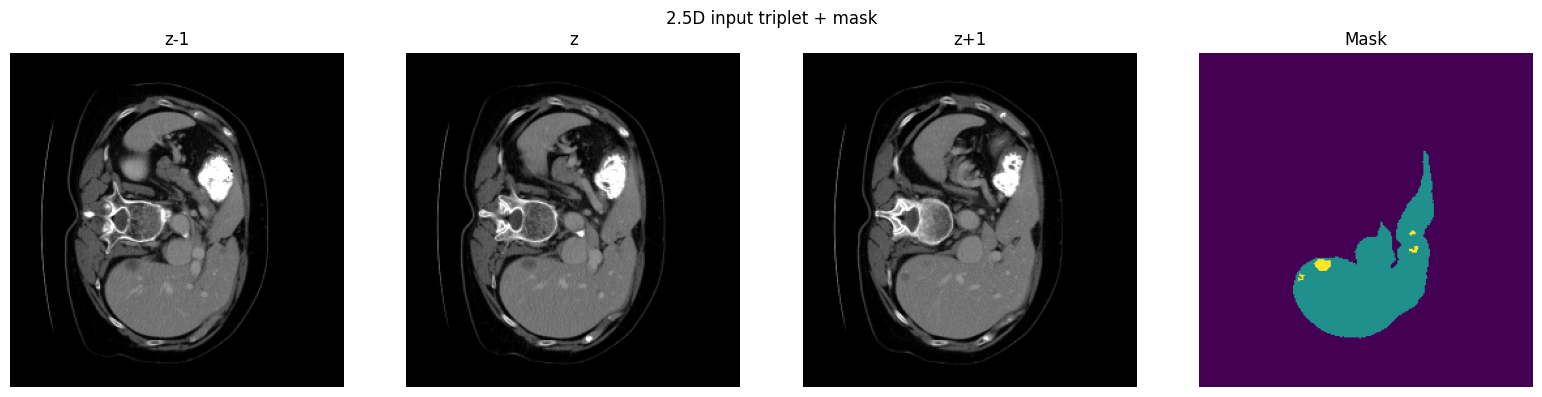

In [12]:
idx = imgs.shape[0] // 2

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ch, ax in enumerate(axes[:3]):
    ax.imshow(imgs[idx, ch], cmap="gray")
    ax.set_title(["z-1", "z", "z+1"][ch])
    ax.axis("off")
axes[3].imshow(msks[idx], cmap="viridis", vmin=0, vmax=2)
axes[3].set_title("Mask")
axes[3].axis("off")
plt.suptitle("2.5D input triplet + mask")
plt.tight_layout()
plt.show()

## 10. Cache Test Volumes (inference only — no masks)

In [16]:
# Check free space first
import shutil
total, used, free = shutil.disk_usage(IMG_CACHE)
print(f"Free space: {free / 1e9:.1f} GB")

Free space: 13.1 GB


In [17]:
# Re-load stats from file so this cell is standalone
with open(STATS_FILE) as fh:
    stats = json.load(fh)
GLOBAL_MEAN = stats["mean"]
GLOBAL_STD  = stats["std"]

test_files = sorted([
    f for f in os.listdir(IMAGES_TS_DIR)
    if f.endswith(".nii.gz") and not f.startswith("._")
])
for file in tqdm(test_files, desc="Caching test"):
    ct      = nib.load(os.path.join(IMAGES_TS_DIR, file)).get_fdata()
    ct_norm = preprocess_ct(ct, GLOBAL_MEAN, GLOBAL_STD)

    slices = []
    for z in range(ct_norm.shape[2]):
        triplet = make_25d(ct_norm, z, RESIZE)   # (H,W,3)
        slices.append(triplet.astype(np.float32).transpose(2, 0, 1))  # (3,H,W)

    stem = file.replace(".nii.gz", "")
    np.save(os.path.join(TEST_IMG_CACHE, f"{stem}.npy"), np.stack(slices))

print("✅ Test preprocessing complete.")

Caching test: 100%|████████████████████████████████████████████████████████████████████| 70/70 [08:58<00:00,  7.69s/it]

✅ Test preprocessing complete.


## 11. Final Summary

In [18]:
n_train_vols = len(train_files)
n_val_vols   = len(val_files)
n_test_vols  = len(test_files)

n_train_slices = sum(
    np.load(os.path.join(IMG_CACHE, f), mmap_mode="r").shape[0]
    for f in os.listdir(IMG_CACHE)
    if f.replace(".npy", ".nii.gz") in train_files
)
n_val_slices = sum(
    np.load(os.path.join(IMG_CACHE, f), mmap_mode="r").shape[0]
    for f in os.listdir(IMG_CACHE)
    if f.replace(".npy", ".nii.gz") in val_files
)

print("==============================")
print(f" Train : {n_train_vols:>3} volumes  {n_train_slices:>6} slices")
print(f" Val   : {n_val_vols:>3} volumes  {n_val_slices:>6} slices")
print(f" Test  : {n_test_vols:>3} volumes")
print("==============================")
print(f" Split file  → {SPLIT_FILE}")
print(f" Stats file  → {STATS_FILE}")
print("\n✅ Preprocessing complete — ready for Notebook 2.")

 Train : 104 volumes   18122 slices
 Val   :  27 volumes    4985 slices
 Test  :  70 volumes
 Split file  → msd_liver_cache_v2\patient_split.json
 Stats file  → msd_liver_cache_v2\intensity_stats.json

✅ Preprocessing complete — ready for Notebook 2.
